## Revenue Forecasting & Sales Intelligence Project
### Objective 
This project focuses on analyzing historical sales data and building a forecasting model to predict revenue for the next 30–60 days. The goal is to generate actionable insights that help in decision-making such as demand planning, inventory management, and identifying high-performing regions and categories.

In [1]:
import numpy as np 
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error , mean_squared_error
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from prophet import Prophet

In [2]:
sales_data = pd.read_csv("sales_data_intermediate.csv")

### Data Understanding

The dataset contains historical sales records with the following key features:
- Date: Transaction date
- Sales: Revenue generated
- Category: Product category
- Region: Sales region
  
The dataset is time-series in nature, making it suitable for trend analysis and forecasting.

In [3]:
sales_data.shape

(4500, 7)

In [4]:
sales_data.head()

,order_id,date,product_id,category,sales,quantity,region
0,ORD100000,2022-08-17,PROD1031,Electronics,146.10,5,Midwest
1,ORD100001,2023-04-03,PROD1086,Clothing,78.50,5,West
2,ORD100002,2022-06-28,PROD1004,Sports,165.34,2,South
3,ORD100003,2022-03-03,PROD1029,Electronics,NaN,3,East
4,ORD100004,2024-10-31,PROD1071,Sports,163.45,5,West


In [5]:
sales_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4500 entries, 0 to 4499
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   order_id    4500 non-null   object 
 1   date        4500 non-null   object 
 2   product_id  4500 non-null   object 
 3   category    4410 non-null   object 
 4   sales       4410 non-null   float64
 5   quantity    4500 non-null   int64  
 6   region      4500 non-null   object 
dtypes: float64(1), int64(1), object(5)
memory usage: 246.2+ KB


### Missing Value Treatment 

Missing values in the category column were removed to avoid incorrect labeling, while missing values in sales were handled using interpolation to maintain the continuity of time series data. The dataset was also sorted chronologically after converting the date column into datetime format.

In [6]:
sales_data.isnull().sum()

order_id       0
date           0
product_id     0
category      90
sales         90
quantity       0
region         0
dtype: int64

In [7]:
sales_data['date'] = pd.to_datetime(sales_data['date'])

In [8]:
# Sort data by date and handle missing values

sales_data = sales_data.sort_values('date')
sales_data = sales_data.dropna(subset=['category'])
sales_data['sales'] = sales_data['sales'].ffill()

Missing values in the sales data were handled using forward fill to ensure that only past data is used, thereby avoiding data leakage and maintaining realistic forecasting.

### Feature Engineering 
To capture temporal patterns and dependencies in the data, several time-based features were engineered. Lag features were created to incorporate past sales information, while rolling statistics were used to capture short-term trends and variability. Additionally, time-based features such as day of the week were included to account for potential seasonal effects. These features help the model better understand historical patterns and improve prediction accuracy.

In [9]:
sales_daily = sales_data.groupby('date')['sales'].sum().reset_index()
sales_daily = sales_daily.sort_values('date')

In [10]:
# Creating features based on past sales trends (lag & rolling)

sales_daily['lag_1'] = sales_daily['sales'].shift(1)
sales_daily['lag_7'] = sales_daily['sales'].shift(7)
sales_daily['lag_14'] = sales_daily['sales'].shift(14)
sales_daily['lag_21'] = sales_daily['sales'].shift(21)
sales_daily['lag_30'] = sales_daily['sales'].shift(30)

sales_daily['rolling_mean_7'] = sales_daily['sales'].shift(1).rolling(7).mean()
sales_daily['rolling_std_7'] = sales_daily['sales'].shift(1).rolling(7).std()
sales_daily['rolling_mean_14'] = sales_daily['sales'].shift(1).rolling(14).mean()
sales_daily['rolling_std_14'] = sales_daily['sales'].shift(1).rolling(14).std()

In [11]:
sales_daily = sales_daily.dropna()

In [12]:
# Convert categorical 'day_of_week' into numerical features using one-hot encoding to capture weekly patterns

sales_daily['day_of_week'] = sales_daily['date'].dt.day_name()
sales_daily = pd.get_dummies(sales_daily, columns=['day_of_week'], drop_first=True)

In [13]:
sales_daily = sales_daily.astype({col: 'int' for col in sales_daily.select_dtypes('bool').columns})

In [14]:
X = sales_daily.drop(columns=['sales','date'])
y = sales_daily['sales']

### Exploratory Data Analysis

##### Daily Sales Trend
Sales vary a lot over time with some spikes, showing changes in demand and possible seasonal or promotional effects.

<Axes: title={'center': 'Daily sales trend'}>

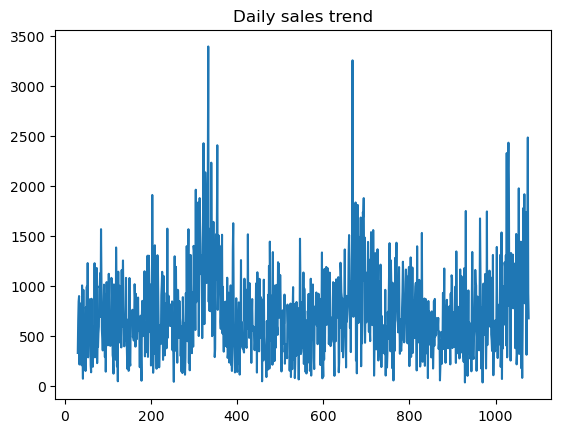

In [15]:
sales_daily['sales'].plot(title = 'Daily sales trend')

##### Category-wise Sales
Electronics has the highest sales, followed by other categories, indicating it is the most important revenue contributor.

<Axes: xlabel='category'>

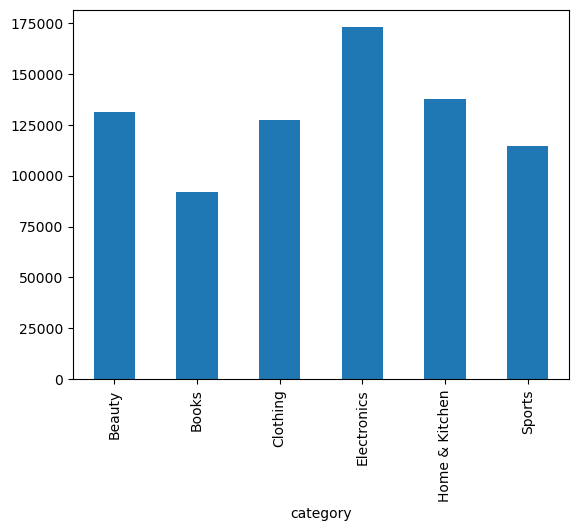

In [16]:
sales_data.groupby('category')['sales'].sum().plot(kind = 'bar')

##### Region-wise Sales

The West region performs the best, while Midwest has lower sales, showing differences in demand across regions.

<Axes: xlabel='region'>

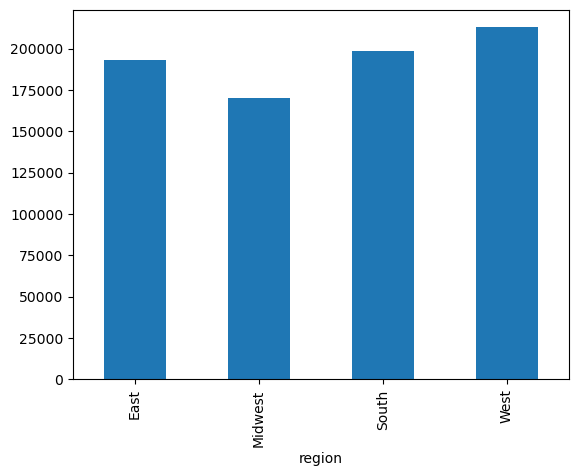

In [17]:
sales_data.groupby('region')['sales'].sum().plot(kind = 'bar')

##### 30-Day Rolling Trend

The rolling average smooths daily fluctuations and shows the overall trend more clearly, highlighting patterns over time.

<Axes: title={'center': '30-day Trend'}>

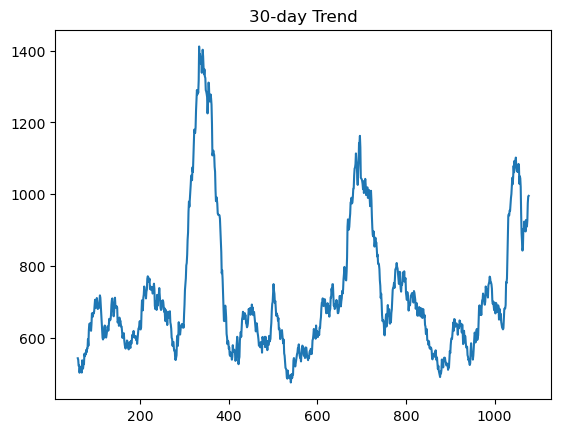

In [18]:
sales_daily['sales'].rolling(30).mean().plot(title="30-day Trend")

##### Monthly Sales Trend

Monthly data shows broader trends and helps identify seasonal patterns and long-term changes in sales.

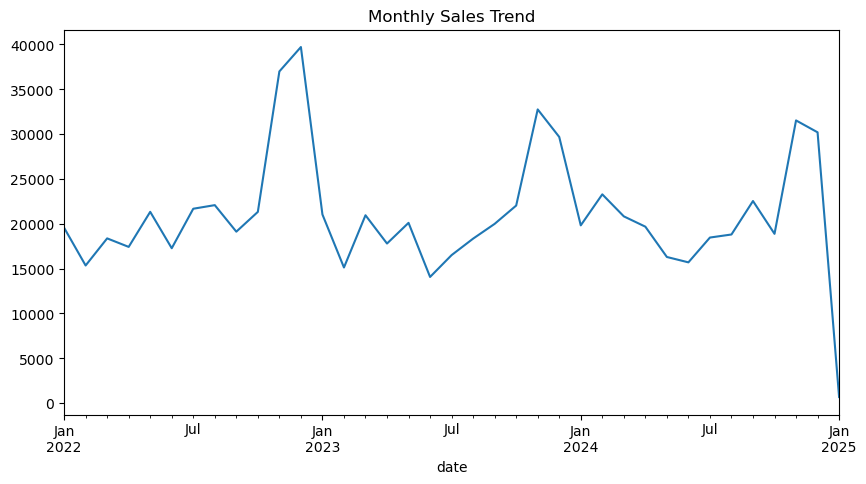

In [19]:
monthly_sales = sales_data.groupby(sales_data['date'].dt.to_period('M'))['sales'].sum()

monthly_sales.plot(figsize=(10,5), title="Monthly Sales Trend")
plt.show()

##### Sales Distribution

Most sales fall within a common range, with a few higher values, indicating occasional spikes in demand.

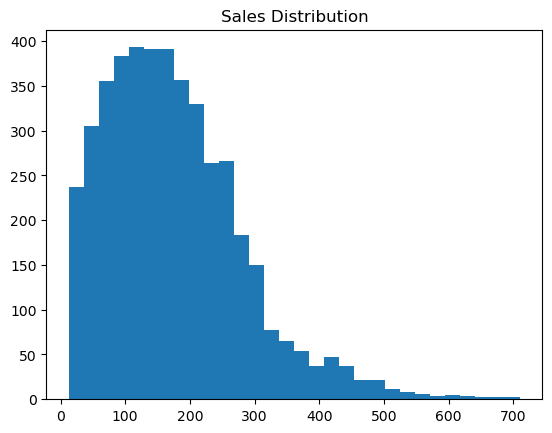

In [20]:
plt.hist(sales_data['sales'], bins=30)
plt.title("Sales Distribution")
plt.show()

### Modeling & Evaluation

A Random Forest model was trained to predict sales using past data. The data was split into training and testing sets in time order. The model was evaluated using MAE and RMSE to check how accurate the predictions are.

In [21]:
# Create features/target and perform 80-20 time-based train-test split.

x = sales_daily.drop(columns=['sales','date'])
y = sales_daily['sales']

split = int(len(sales_daily)* 0.8)
x_train,x_test = x[:split],x[split:]
y_train,y_test = y[:split],y[split:]

In [22]:
# Training model using time-based cross-validation

tscv = TimeSeriesSplit(n_splits=5)

mae_scores = []
rmse_scores = []

for train_index, test_index in tscv.split(x):

    X_train_cv, X_test_cv = x.iloc[train_index], x.iloc[test_index]
    y_train_cv, y_test_cv = y.iloc[train_index], y.iloc[test_index]

    model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
    model.fit(X_train_cv, y_train_cv)

    y_pred_cv = model.predict(X_test_cv)

    mae_scores.append(mean_absolute_error(y_test_cv, y_pred_cv))
    rmse_scores.append(np.sqrt(mean_squared_error(y_test_cv, y_pred_cv)))

print(f"Cross-Validation Results → MAE: {np.mean(mae_scores):.2f}, RMSE: {np.mean(rmse_scores):.2f}")

Cross-Validation Results → MAE: 346.07, RMSE: 452.41


In [23]:
# Train Random Forest model on training data

rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    random_state=42
)
rf_model.fit(x_train,y_train)

RandomForestRegressor(max_depth=10, random_state=42)

In [24]:
# Generating predictions on test data

y_pred_rf = rf_model.predict(x_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("Random Forest MAE:", mae_rf)
print("Random Forest RMSE:", rmse_rf)

Random Forest MAE: 345.08894153277714
Random Forest RMSE: 455.96294296974304


The model achieves an MAE of ~348 and RMSE of ~459. This indicates that the model predictions differ from actual values by around 350 units on average.

In [25]:
print("\nInsight: Cross-validation and test results are similar, indicating the model is stable and not overfitting.")


Insight: Cross-validation and test results are similar, indicating the model is stable and not overfitting.


### Final Forecasting Model
To improve forecasting accuracy and capture time-based patterns such as trend and seasonality, the Prophet model was used. It is specifically designed for time series data and provides reliable future sales predictions based on historical trends.

02:22:18 - cmdstanpy - INFO - Chain [1] start processing
02:22:19 - cmdstanpy - INFO - Chain [1] done processing


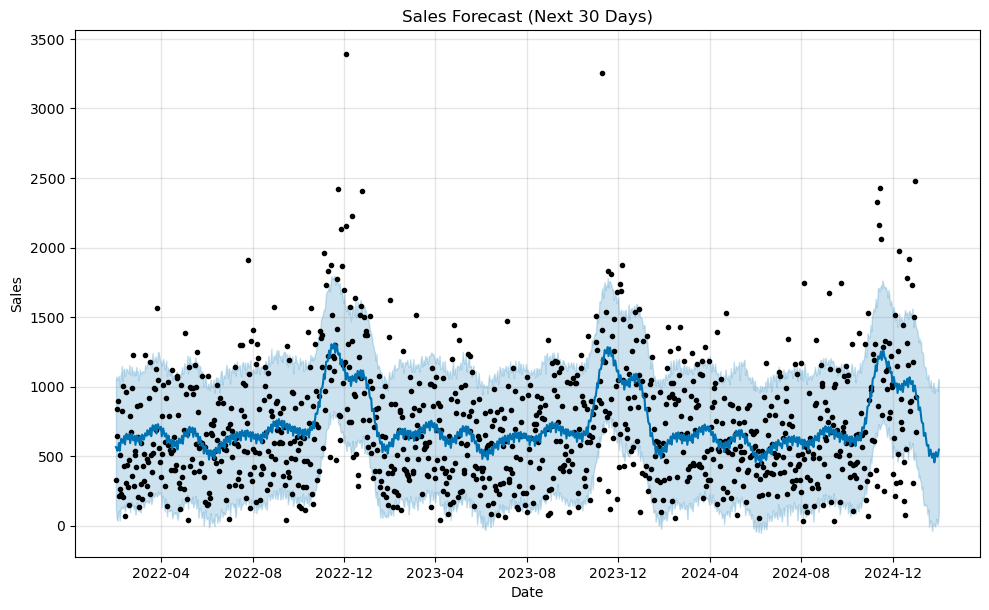

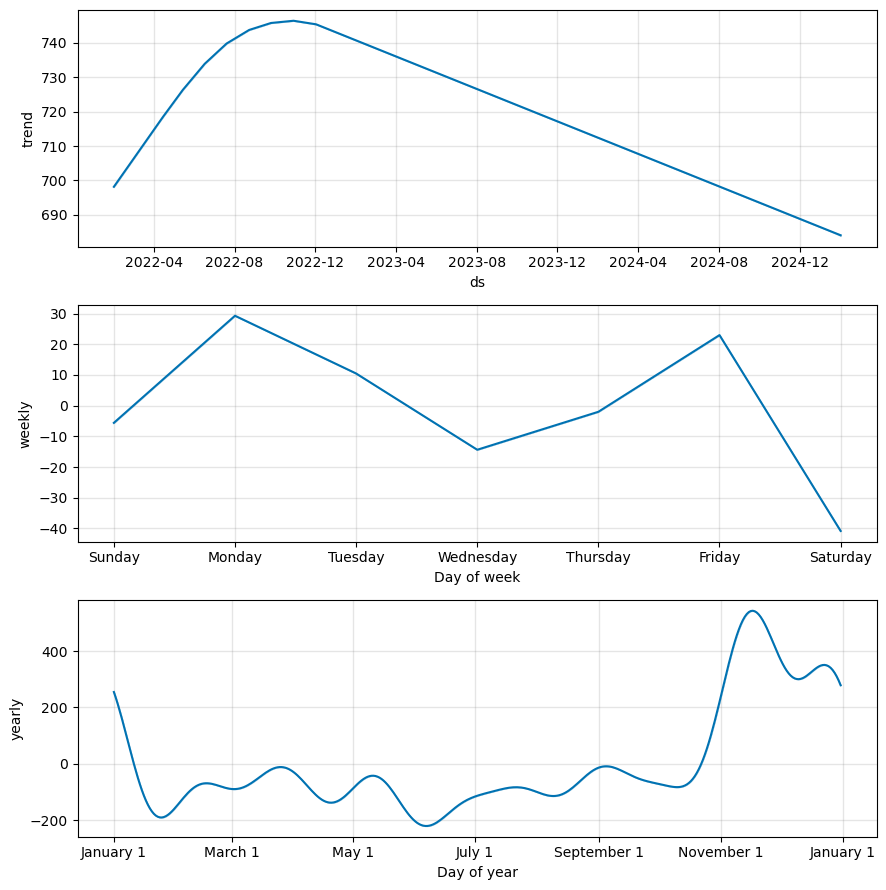

In [26]:
# Preparing data for Prophet forecasting model

df_prophet = sales_daily[['date', 'sales']]
df_prophet.columns = ['ds', 'y']

model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    changepoint_prior_scale=0.1
)
model.fit(df_prophet)

future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

fig1 = model.plot(forecast)
plt.title("Sales Forecast (Next 30 Days)")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

fig2 = model.plot_components(forecast)
plt.show()

In [27]:
# Evaluate Prophet model performance using MAE and RMSE

prophet_preds = forecast['yhat'][-len(y_test):].values

mae_prophet = mean_absolute_error(y_test, prophet_preds)
rmse_prophet = np.sqrt(mean_squared_error(y_test, prophet_preds))

print(f"Prophet Results → MAE: {mae_prophet:.2f}, RMSE: {rmse_prophet:.2f}")

Prophet Results → MAE: 384.41, RMSE: 501.05


In [28]:
# Compare performance of Random Forest and Prophet models

print("\nModel Comparison:")
print(f"Random Forest → MAE: {mae_rf:.2f}, RMSE: {rmse_rf:.2f}")
print(f"Prophet       → MAE: {mae_prophet:.2f}, RMSE: {rmse_prophet:.2f}")


Model Comparison:
Random Forest → MAE: 345.09, RMSE: 455.96
Prophet       → MAE: 384.41, RMSE: 501.05


The average daily sales is around 800–1000, so an MAE of approximately 350 (rounded from 348.19) represents an error of about 35–40%. This indicates moderate prediction accuracy, which is acceptable for short-term forecasting.

In [29]:
# Select best model based on lower error metric (MAE)

if mae_rf < mae_prophet:
    print("\nConclusion: Random Forest performs better for this dataset.")
else:
    print("\nConclusion: Prophet performs better for this dataset.")


Conclusion: Random Forest performs better for this dataset.


### Model Comparison Insights:
Random Forest achieved slightly better accuracy (lower MAE and RMSE), indicating strong performance in capturing short-term patterns. 
However, Prophet is selected as the final forecasting model because it clearly captures trend and seasonality, making it easier to interpret and more suitable for business decision-making.

### Actual vs Predicted Sales

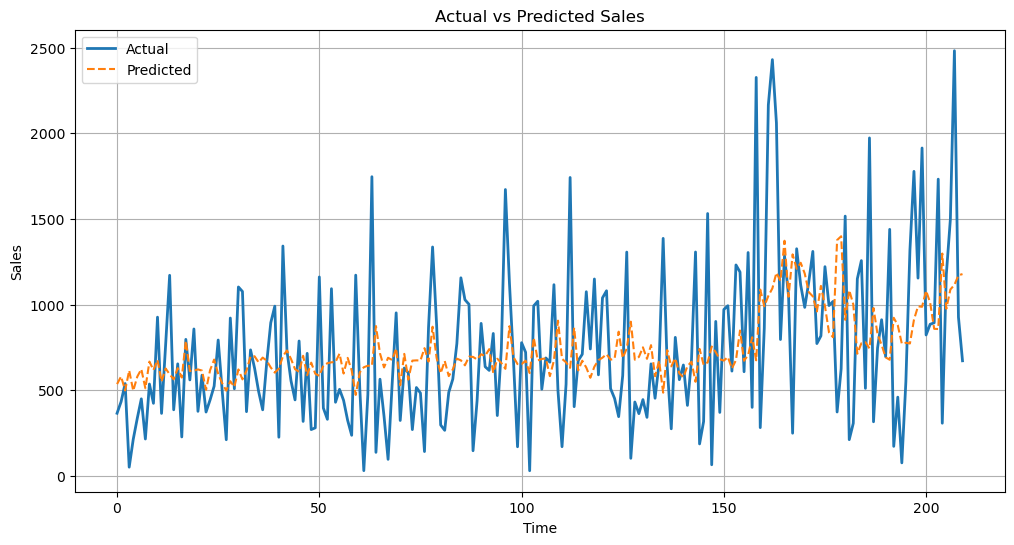

In [30]:
# Visualizing actual vs predicted sales for model evaluation

plt.figure(figsize=(12,6))

plt.plot(y_test.values, label='Actual', linewidth=2)
plt.plot(y_pred_rf, label='Predicted', linestyle='--')

plt.title("Actual vs Predicted Sales")
plt.xlabel("Time")
plt.ylabel("Sales")
plt.legend()
plt.grid()

plt.show()

### Feature Importance Analysis

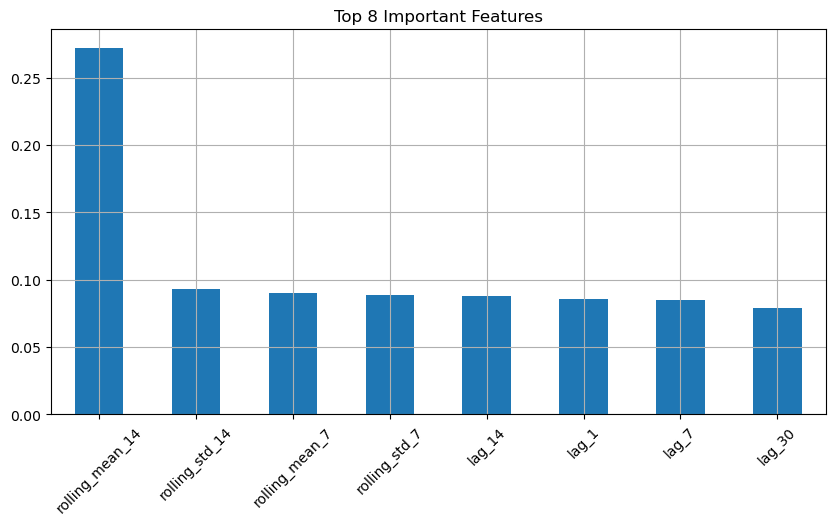

In [31]:
# Analyze feature importance to identify key drivers of sales predictions

feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns)

top_features = feature_importance.sort_values(ascending=False).head(8)

plt.figure(figsize=(10,5))
top_features.plot(kind='bar')
plt.title("Top 8 Important Features")
plt.xticks(rotation=45)
plt.grid()
plt.show()

- Rolling mean (14 days) is the most influential feature, indicating that recent sales trends strongly impact future predictions. 
- Lag features (7 and 14 days) also contribute significantly, showing that past sales patterns are important predictors.
- Day-of-week features have relatively lower importance, suggesting that short-term daily variations have less impact compared to overall trends.

### Future Sales Forecast 
The Prophet model is used to forecast sales for the next 30 days using historical data. It captures important patterns such as trend and seasonality, helping to generate reliable future predictions.

02:22:26 - cmdstanpy - INFO - Chain [1] start processing
02:22:26 - cmdstanpy - INFO - Chain [1] done processing


2025-01-02 -> 926.94
2025-01-03 -> 929.35
2025-01-04 -> 841.51
2025-01-05 -> 851.46
2025-01-06 -> 860.10
2025-01-07 -> 814.66
2025-01-08 -> 762.82
2025-01-09 -> 748.23
2025-01-10 -> 746.61
2025-01-11 -> 656.75
2025-01-12 -> 666.71
2025-01-13 -> 677.40
2025-01-14 -> 635.97
2025-01-15 -> 590.03
2025-01-16 -> 583.10
2025-01-17 -> 590.75
2025-01-18 -> 511.60
2025-01-19 -> 533.50
2025-01-20 -> 557.15
2025-01-21 -> 529.47
2025-01-22 -> 497.83
2025-01-23 -> 505.52
2025-01-24 -> 527.86
2025-01-25 -> 463.25
2025-01-26 -> 499.32
2025-01-27 -> 536.56
2025-01-28 -> 521.70
2025-01-29 -> 501.96
2025-01-30 -> 520.47
2025-01-31 -> 552.45


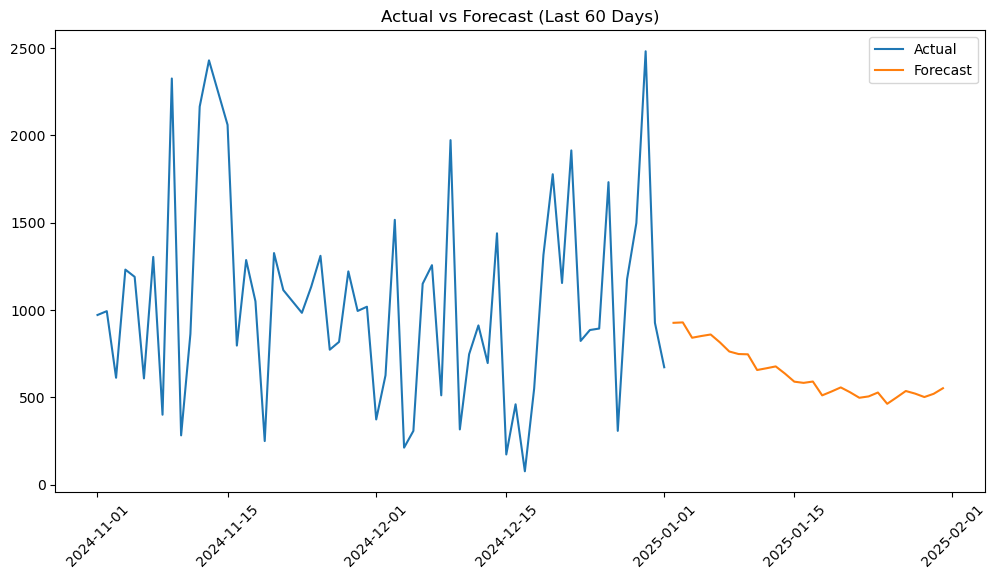

In [32]:
# Prepare data and train Prophet model for sales forecasting
df_prophet = sales_daily[['date', 'sales']].copy()
df_prophet.columns = ['ds', 'y']

model = Prophet()
model.fit(df_prophet)

# Generate future dates and predict sales for next 30 days
future = model.make_future_dataframe(periods=30)

forecast = model.predict(future)

# Extract last 30 days forecasted values
forecast_future = forecast[['ds', 'yhat']].tail(30)

for i, row in forecast_future.iterrows():
    print(f"{row['ds'].date()} -> {row['yhat']:.2f}")

# Plot actual vs forecasted sales for recent period
recent_data = df_prophet.tail(60)

plt.figure(figsize=(12,6))
plt.plot(recent_data['ds'], recent_data['y'], label='Actual')
plt.plot(forecast_future['ds'], forecast_future['yhat'], label='Forecast')

plt.legend()
plt.title("Actual vs Forecast (Last 60 Days)")
plt.xticks(rotation=45)
plt.show()

The forecast follows the overall trend of recent data, though it smooths out sharp spikes, indicating stable expected demand in the coming days.

### Forecast Horizon:

The model generates a 30-day forecast as the primary output to ensure higher accuracy and reliability.

The model can also be extended to generate forecasts up to 60 days, though uncertainty increases with longer horizons. Therefore, the 30-day forecast is recommended for operational decision-making.

### Forecast Export & Visualization
The trained forecasting model is saved for future use, and the predicted sales for the next 30 days are structured into a clean dataset. The forecast results are then exported as a CSV file for business use and further analysis. A line plot is also created to visualize the predicted sales trend over the upcoming days.

In [33]:
# Save trained forecasting model for future use

import joblib

joblib.dump(model, "sales_forecast_model.pkl")

forecast_future = forecast[['ds', 'yhat']].tail(30).copy()

forecast_df = forecast_future.rename(columns={
    'ds': 'Date',
    'yhat': 'Predicted Sales'
})

forecast_df['Predicted Sales'] = forecast_df['Predicted Sales'].round(2)

forecast_df['Date'] = pd.to_datetime(forecast_df['Date']).dt.strftime('%Y-%m-%d')

print(forecast_df.head())

forecast_df.to_csv("sales_forecast_output.csv", index=False)

            Date  Predicted Sales
1048  2025-01-02           926.94
1049  2025-01-03           929.35
1050  2025-01-04           841.51
1051  2025-01-05           851.46
1052  2025-01-06           860.10


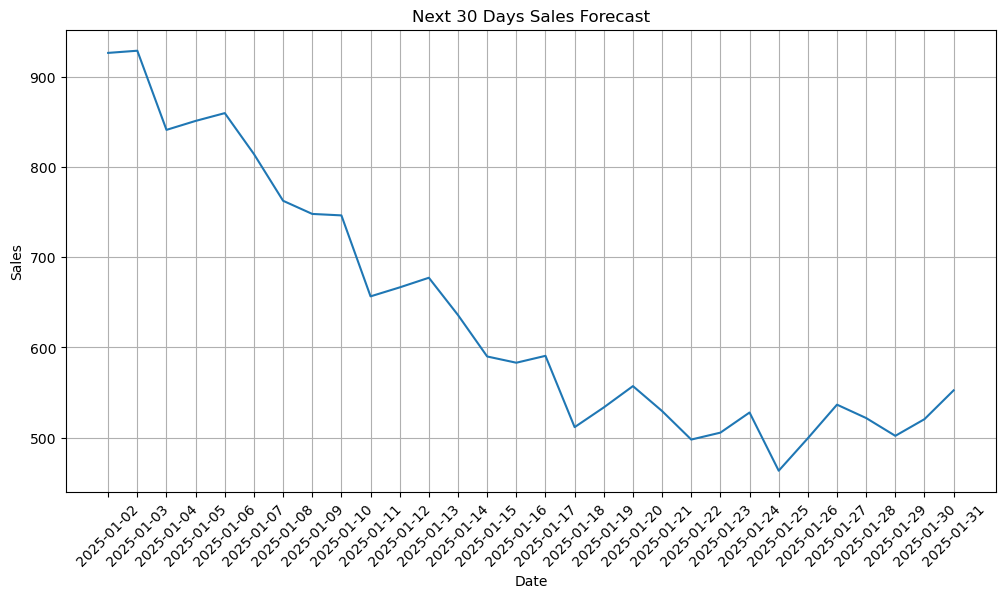

In [34]:
# Visualize predicted sales trend for the next 30 days

plt.figure(figsize=(12,6))

plt.plot(forecast_df['Date'], forecast_df['Predicted Sales'])

plt.title("Next 30 Days Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.grid()

plt.show()

### Model Explanation

A Random Forest model was used as a baseline to learn patterns from lag features and rolling averages. While it performed reasonably well, it does not explicitly model time-based components such as trend and seasonality.

The final model uses Prophet, which is specifically designed for time series forecasting. It captures trend and seasonal patterns directly from historical time-based data, making it more suitable for short-term business forecasting.

A time-based split ensures that predictions are generated using only past data, reflecting real-world conditions. Since recent sales trends (last 7–14 days) strongly influence demand, the model is well-suited for short-term forecasting (30 days) and supports effective planning decisions.

### Business Insights
- Electronics contributes 22% (171K) of total revenue, making it the primary driver of overall sales performance.
- The West region generates 27% (213K) of total revenue, indicating the strongest regional demand.
- Sales exhibit seasonal spikes, highlighting predictable demand patterns for planning and promotions.
- Recent sales trends (last 7–14 days) have the highest impact on future demand, making them critical for short-term forecasting.
### Recommendations

- Focus on the West region (27% contribution) to maximize revenue growth.
- Prioritize Electronics (22% contribution) for targeted promotions and inventory planning.
- Align inventory and marketing strategies with peak seasonal demand periods.
- Use recent sales trends (7–14 days) for short-term demand forecasting and stock planning.
- Improve inventory management to reduce stockouts and overstock risks.
### Conclusion

This analysis identifies Electronics and the West region as key revenue drivers, supported by consistent seasonal demand patterns. The forecasting model effectively captures recent trends, enabling reliable short-term planning and informed business decision-making.